Порог детекции пиков (правое колено): V_peak = 7.27 мВ
Интегрирование траекторий для различных пре-стимульных токов...


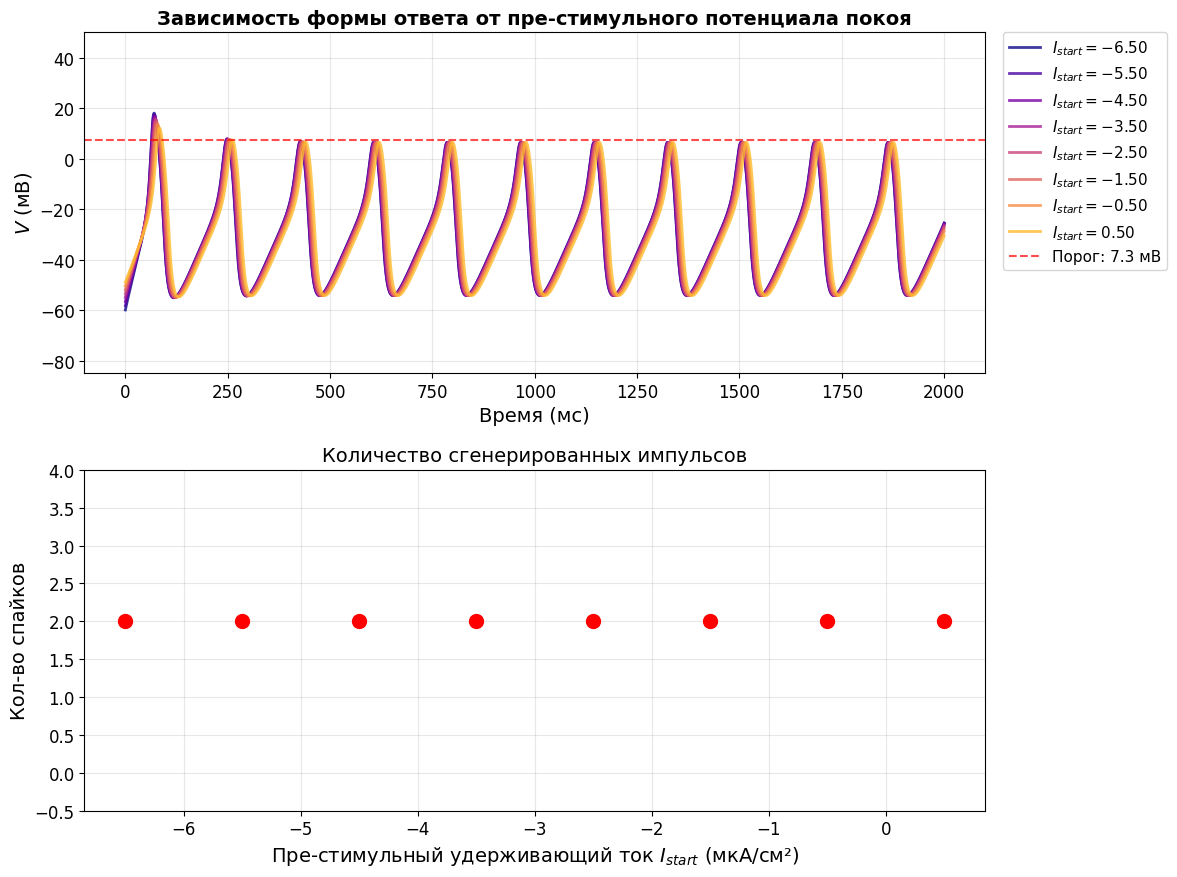

In [1]:
"""
Morris-Lecar Model: Dependence of Spiking Dynamics on Initial Conditions.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.signal import find_peaks

# Настройка шрифтов для графиков высокой четкости
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
})

# Константы модели Морриса-Лекара
PARAMS = {
    'C': 20.0, 'g_leak': 0.20, 'V_leak': -50.0,
    'g_Ca': 4.4, 'V_Ca': 100.0, 'g_K': 8.0, 'V_K': -70.0,
    'V1': -1.0, 'V2': 15.0, 'V3': 2.0, 'V4': 30.0, 'phi': 0.05
}

def inf_m(V):
    return 1 / (1 + np.exp((PARAMS['V1'] - V) / PARAMS['V2']))

def inf_n(V):
    return 1 / (1 + np.exp((PARAMS['V3'] - V) / PARAMS['V4']))

def V0_for_I_start(I_start):
    """Нахождение стационарного потенциала покоя для заданного начального тока."""
    def eq(V):
        m_inf = inf_m(V)
        n_inf = inf_n(V)
        I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
        I_Ca = PARAMS['g_Ca'] * m_inf * (V - PARAMS['V_Ca'])
        I_K = PARAMS['g_K'] * n_inf * (V - PARAMS['V_K'])
        return (-I_leak - I_Ca - I_K + I_start) / PARAMS['C']
    return fsolve(eq, -60.0)[0]

def morris_lecar(t, y, I):
    """Правая часть системы уравнений Морриса-Лекара."""
    V, n = y
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * inf_m(V) * (V - PARAMS['V_Ca'])
    I_K = PARAMS['g_K'] * n * (V - PARAMS['V_K'])
    dVdt = (-I_leak - I_Ca - I_K + I) / PARAMS['C']
    dn_dt = PARAMS['phi'] * (inf_n(V) - n)
    return [dVdt, dn_dt]

def find_right_knee_V(I, show_plot=True):
    """Нахождение точки правого колена V-изоклины (где dn/dV = 0)."""

    def n_nullcline(V):
        """Значение n на изоклине dV/dt = 0."""
        m_inf = inf_m(V)
        I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
        I_Ca = PARAMS['g_Ca'] * m_inf * (V - PARAMS['V_Ca'])
        denom = PARAMS['g_K'] * (V - PARAMS['V_K'])
        if abs(denom) < 1e-10:
            return 0.0
        return np.clip((I - I_leak - I_Ca) / denom, 0, 1)

    def dn_dV(V):
        """Центральная численная производная dn/dV."""
        dV = 0.1
        return (n_nullcline(V + dV) - n_nullcline(V - dV)) / (2 * dV)

    if show_plot:
        V_range = np.linspace(0, 20, 500)
        n_values = np.array([n_nullcline(v) for v in V_range])
        dn_values = np.array([dn_dV(v) for v in V_range])

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

        # График изоклины
        ax1.plot(V_range, n_values, 'b-', linewidth=2.5, label=r'$n(V)$ при $\dot{V}=0$')
        ax1.set_ylabel('$n$')
        ax1.set_title(f'V-нульклинический анализ ($I = {I}$ мкА/см²)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        # График производной
        ax2.plot(V_range, dn_values, 'r-', linewidth=2.5, label=r'$dn/dV$')
        ax2.axhline(0, color='k', linestyle='--', alpha=0.6)
        ax2.set_xlabel('$V$ (мВ)')
        ax2.set_ylabel('$dn/dV$')
        ax2.grid(True, alpha=0.3)
        ax2.legend()

        plt.tight_layout()
        plt.show()

    # Поиск нуля производной, начиная с +5 мВ
    V_knee = fsolve(dn_dV, 5.0)[0]
    return V_knee

def main():
    I_final = 8.95
    # Поиск динамического порога
    V_peak_threshold = find_right_knee_V(I_final, show_plot=False)
    print(f"Порог детекции пиков (правое колено): V_peak = {V_peak_threshold:.2f} мВ")

    I_start_currents = np.linspace(-6.5, 0.5, 8)
    V_solutions_start = []
    spike_counts_start = []

    t_span = [0, 2000]
    t_eval = np.linspace(0, 2000, 10000)

    print("Интегрирование траекторий для различных пре-стимульных токов...")
    for I_start in I_start_currents:
        # Устанавливаем начальное состояние по пре-стимульному току
        V0 = V0_for_I_start(I_start)
        y0 = [V0, inf_n(V0)]

        # Симуляция ответа при мгновенном переключении на I_final в момент t=0
        sol = solve_ivp(lambda t, y: morris_lecar(t, y, I_final),
                        t_span, y0, t_eval=t_eval, method='LSODA', rtol=1e-6)

        peaks, _ = find_peaks(sol.y[0], height=V_peak_threshold, distance=50)
        V_solutions_start.append(sol)
        spike_counts_start.append(len(peaks))

    # --- СТРОИМ ФИНАЛЬНЫЕ ГРАФИКИ ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))
    colors = plt.cm.plasma(np.linspace(0, 0.85, len(I_start_currents)))

    # Верхний график: Временная развёртка потенциала
    for i, sol in enumerate(V_solutions_start):
        ax1.plot(sol.t, sol.y[0], color=colors[i], lw=2, alpha=0.8,
                 label=f'$I_{{start}} = {I_start_currents[i]:.2f}$')

    ax1.axhline(V_peak_threshold, color='red', ls='--', alpha=0.7,
                label=f'Порог: {V_peak_threshold:.1f} мВ')
    ax1.set_xlabel('Время (мс)')
    ax1.set_ylabel('$V$ (мВ)')
    ax1.set_title('Зависимость формы ответа от пре-стимульного потенциала покоя', fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-85, 50)

    # Нижний график: Только дискретные точки ('ro' вместо 'ro-')
    ax2.plot(I_start_currents, spike_counts_start, 'ro', markersize=10, label='Количество спайков')
    ax2.set_xlabel('Пре-стимульный удерживающий ток $I_{start}$ (мкА/см²)')
    ax2.set_ylabel('Кол-во спайков')
    ax2.set_title('Количество сгенерированных импульсов')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.5, max(spike_counts_start) + 2)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()